ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [3]:
# Load Dataset
df = pd.read_csv("fastfood.csv")
# Display rows
df.head(-1)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,Taco Bell,Original Triple Double Crunchwrap,700,270,30,9.0,0.5,45,1550,85,9.0,7,23.0,15.0,6.0,25.0,Other
510,Taco Bell,Spicy Triple Double Crunchwrap,780,340,38,10.0,0.5,50,1850,87,9.0,8,23.0,20.0,10.0,25.0,Other
511,Taco Bell,Express Taco Salad w/ Chips,580,260,29,9.0,1.0,60,1270,59,8.0,7,23.0,NaN,NaN,NaN,Other
512,Taco Bell,Fiesta Taco Salad-Beef,780,380,42,10.0,1.0,60,1340,74,11.0,7,26.0,NaN,NaN,NaN,Other


### Check Missing Values

In [4]:
# Check all missing values (True = missing)
print(df.isna())

     restaurant   item  calories  cal_fat  total_fat  sat_fat  trans_fat  \
0         False  False     False    False      False    False      False   
1         False  False     False    False      False    False      False   
2         False  False     False    False      False    False      False   
3         False  False     False    False      False    False      False   
4         False  False     False    False      False    False      False   
..          ...    ...       ...      ...        ...      ...        ...   
510       False  False     False    False      False    False      False   
511       False  False     False    False      False    False      False   
512       False  False     False    False      False    False      False   
513       False  False     False    False      False    False      False   
514       False  False     False    False      False    False      False   

     cholesterol  sodium  total_carb  fiber  sugar  protein  vit_a  vit_c  \
0         

### **Missing value (Before cleaning)**

In [5]:
# Count missing values in each column
print(df.isna().sum())

restaurant       0
item             0
calories         0
cal_fat          0
total_fat        0
sat_fat          0
trans_fat        0
cholesterol      0
sodium           0
total_carb       0
fiber           12
sugar            0
protein          1
vit_a          214
vit_c          210
calcium        210
salad            0
dtype: int64


### Check Duplicate Rows **(Before cleaning)**

In [6]:
# checking duplicate rows
df.duplicated()[df.duplicated() == True]

,0
492,True
511,True


- There is 2 duplicate rows, located at indices 492 and 511.

### No. of Rows and Columns **(Before cleaning)**



In [7]:
# finding number of rows and columns
print("Shape (rows, columns): ", df.shape, "\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (515, 17) 

number of rows:  515
number of columns:  17


### Data Type of Columns

In [8]:
# viewing the data types of columns
df.dtypes

,0
restaurant,object
item,object
calories,int64
cal_fat,int64
total_fat,int64
sat_fat,float64
trans_fat,float64
cholesterol,int64
sodium,int64
total_carb,int64


In [9]:
df['calories'] = pd.to_numeric(df['calories'], errors='coerce')
df['total_fat'] = pd.to_numeric(df['total_fat'], errors='coerce')
df['sodium'] = pd.to_numeric(df['sodium'], errors='coerce')

df.dtypes

,0
restaurant,object
item,object
calories,int64
cal_fat,int64
total_fat,int64
sat_fat,float64
trans_fat,float64
cholesterol,int64
sodium,int64
total_carb,int64


- Ensures that columns like calories, fat, sodium are converted to numeric types (integers/floats).
- The errors='coerce' option will turn invalid entries into NaN (missing values).

In [10]:
# Statistical summary
df.describe(include='all')

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
count,515,515,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,503.000000,515.000000,514.000000,301.000000,305.000000,305.000000,515
unique,8,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,Taco Bell,Crispy Chicken Sandwich,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other
freq,115,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,515
mean,NaN,NaN,530.912621,238.813592,26.590291,8.153398,0.465049,72.456311,1246.737864,45.664078,4.137177,7.262136,27.891051,18.857143,20.170492,24.852459,NaN
std,NaN,NaN,282.436147,166.407510,18.411876,6.418811,0.839644,63.160406,689.954278,24.883342,3.037460,6.761301,17.683921,31.384330,30.592243,25.522073,NaN
min,NaN,NaN,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,330.000000,120.000000,14.000000,4.000000,0.000000,35.000000,800.000000,28.500000,2.000000,3.000000,16.000000,4.000000,4.000000,8.000000,NaN
50%,NaN,NaN,490.000000,210.000000,23.000000,7.000000,0.000000,60.000000,1110.000000,44.000000,3.000000,6.000000,24.500000,10.000000,10.000000,20.000000,NaN
75%,NaN,NaN,690.000000,310.000000,35.000000,11.000000,1.000000,95.000000,1550.000000,57.000000,5.000000,9.000000,36.000000,20.000000,30.000000,30.000000,NaN


### Remove Duplicate Rows **(After Cleaning)**

In [11]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check again
df.duplicated().sum()

np.int64(0)

✏️ Explanation:
- Duplicate rows were removed to avoid repeated data.
- This ensures more accurate analysis.

### Handle Missing Values **(After cleaning)**

In [12]:
# Fill missing values with mean for numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Check again
df.isna().sum()

,0
restaurant,0
item,0
calories,0
cal_fat,0
total_fat,0
sat_fat,0
trans_fat,0
cholesterol,0
sodium,0
total_carb,0


✏️ Explanation:
- Some columns contained missing values (especially vit_a, vit_c, calcium).
- Missing values can affect analysis and visualization.
- We replaced missing values with the mean of each column.
- This keeps the dataset complete without removing too much data.

### Verify Cleaning **(After cleaing)**

In [13]:
# Final check
print("Shape after cleaning:", df.shape)

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape after cleaning: (513, 17)
number of rows:  513
number of columns:  17


✏️ Explanation:
- After cleaning, there should be no missing values.
- Number of rows may decrease after removing duplicates.

## 📊 Univariate Analysis

### 1. Distribution of Calories

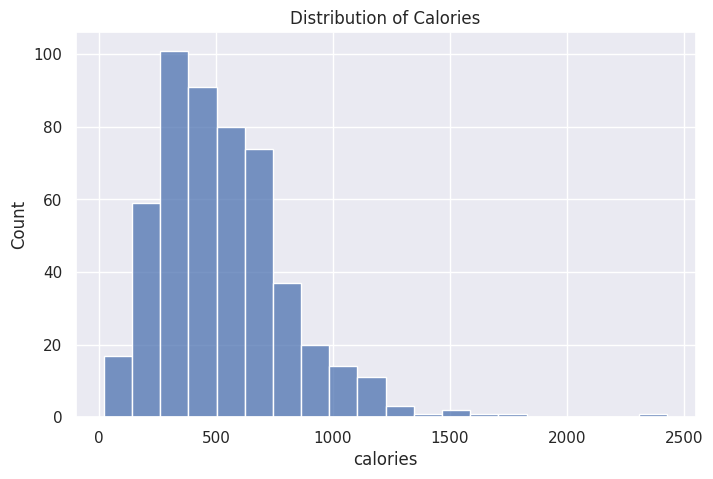

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['calories'], bins=20)
plt.title("Distribution of Calories")
plt.show()

✏️ Explanation:
- Shows how calories are distributed across fast food items.
- Helps identify low vs high calorie foods.
- Why choose this plot? To see how calories are spread across menu items.

💡 Insight:
- Right skewed = many low-calorie items, few very high-calorie ones.
- This is useful for understanding the overall calorie content of fast food.


### 2. Distribution of Total Fat

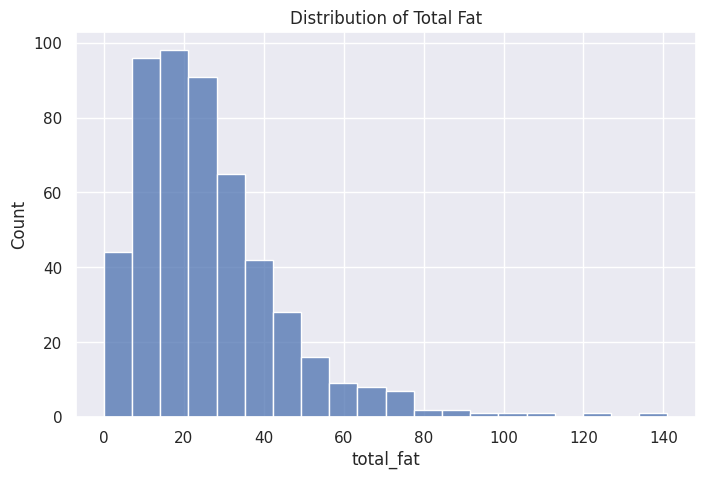

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_fat'], bins=20)
plt.title("Distribution of Total Fat")
plt.show()

✏️ Explanation:
- This histogram visualizes the distribution of fat content in fast food items.
- Why choose this plot? To check fat distribution in items.

💡 Insight:
- right-skewed = Most items are lower in fat, while a small number of items contain a significantly high amount of fat.
- Many fast food items may be lower in fat, but a few have very high fat content, which could be unhealthy.

## 📊 Bivariate Analysis

### 3. Calories by Restaurant

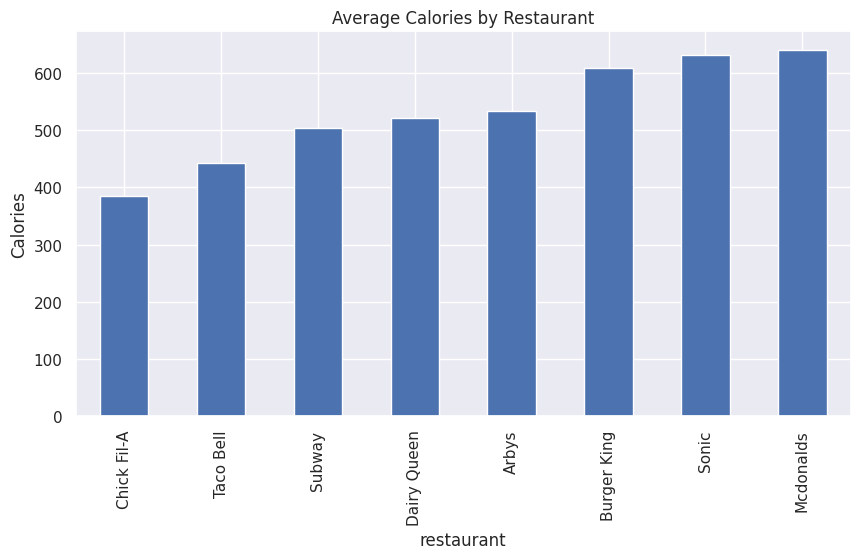

,calories
restaurant,
Chick Fil-A,384.444444
Taco Bell,443.008850
Subway,503.020833
Dairy Queen,520.238095
Arbys,532.727273
Burger King,608.571429
Sonic,631.698113
Mcdonalds,640.350877


In [16]:
restaurant_calories = df.groupby('restaurant')['calories'].mean().sort_values()

plt.figure(figsize=(10,5))
restaurant_calories.plot(kind='bar')
plt.title("Average Calories by Restaurant")
plt.ylabel("Calories")
plt.show()

restaurant_calories

✏️ Explanation:
- Shows the average number of calories in meals from different fast food restaurants.
- Why choose this plot? To compare restaurants.

💡 Insight:
- McDonald’s and Sonic seem to have higher calorie meals on average compared to other restaurants.
- If you’re trying to reduce calorie intake, choosing meals from these restaurants could be less healthy.

### 4. Protein by Restaurant

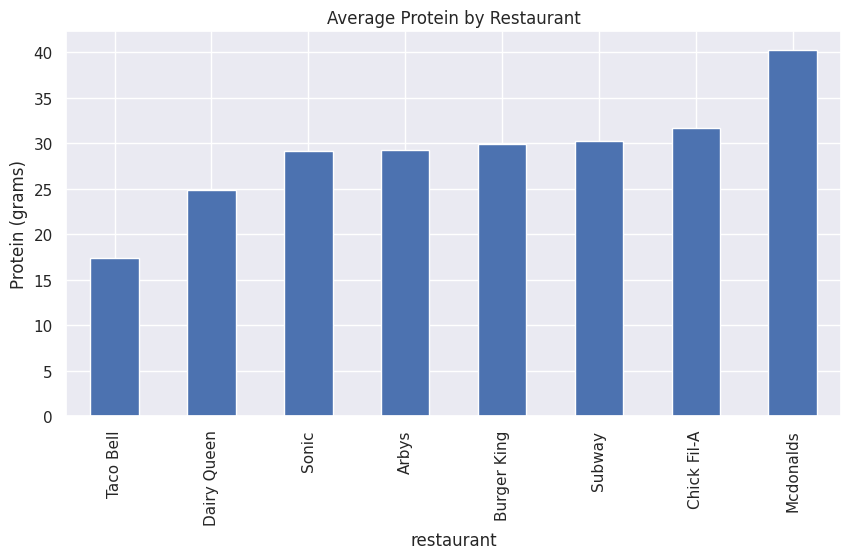

,protein
restaurant,
Taco Bell,17.380531
Dairy Queen,24.833333
Sonic,29.188679
Arbys,29.254545
Burger King,29.984626
Subway,30.312500
Chick Fil-A,31.703704
Mcdonalds,40.298246


In [17]:
restaurant_protein = df.groupby('restaurant')['protein'].mean().sort_values()

plt.figure(figsize=(10,5))
restaurant_protein.plot(kind='bar')
plt.title("Average Protein by Restaurant")
plt.ylabel("Protein (grams)")
plt.show()

restaurant_protein

✏️ Explanation:
- This bar chart visualizes the average protein content per meal from various restaurants.

💡 Insight:
- McDonald’s and Chick Fil-A have higher protein levels in their meals.
- This could suggest that meals from these restaurants may be more protein-rich compared to other options.

### 5. Calories vs Sodium

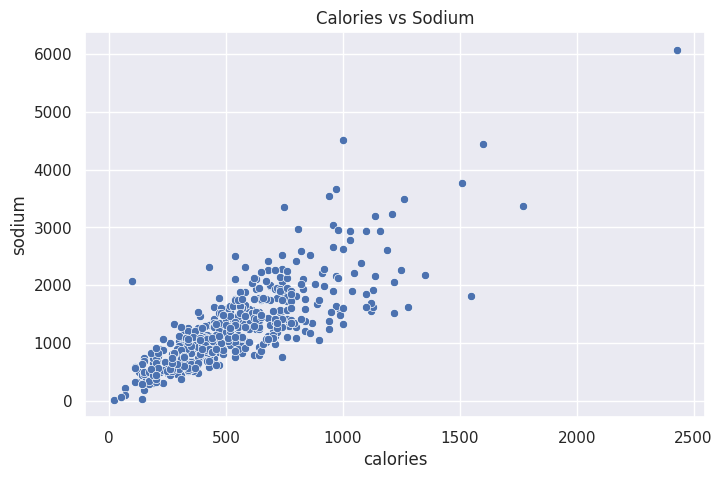

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='calories', y='sodium', data=df)
plt.title("Calories vs Sodium")
plt.show()

✏️ Explanation:
- This scatter plot shows the relationship between calories and sodium content.
- Why choose this plot? To check correlation between calories and sodium

💡 Insight:
- There seems to be a positive correlation between calories and sodium: items with more calories tend to have more sodium.
- This is important because high sodium intake is linked to health risks like high blood pressure, especially when paired with high-calorie foods.


## 📊 Boxplots (To Detect Outliers)

### 6. Calories by Restaurant (Boxplot)

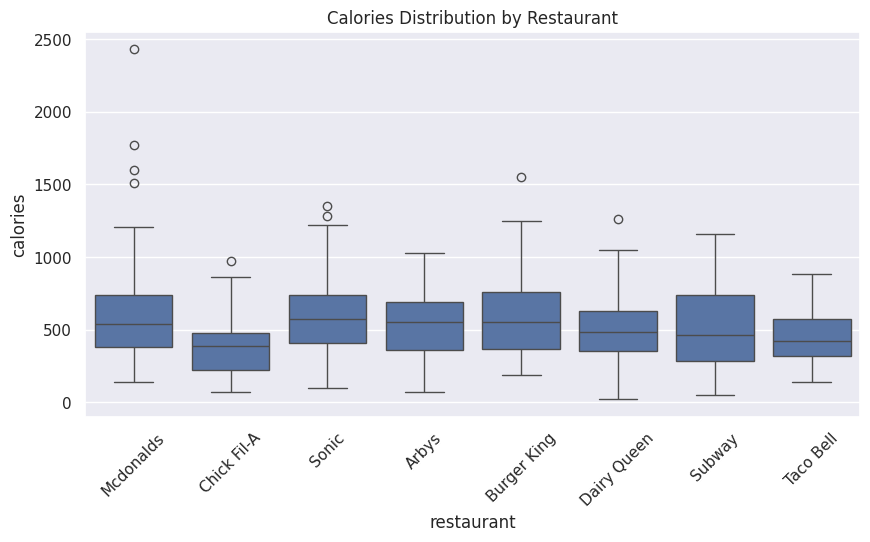

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x='restaurant', y='calories', data=df)
plt.xticks(rotation=45)
plt.title("Calories Distribution by Restaurant")
plt.show()

✏️ Explanation:
- The boxplot shows the distribution of calories for each restaurant.
- It helps visualize the median, quartiles, and outliers in the calorie content across restaurants.

💡 Insight:
- Some restaurants have meals with very high calorie content, as seen by the outliers (points outside the “whiskers”).
- You may want to be cautious when choosing meals from restaurants with larger calorie ranges.


## 📊 Correlation Analysis

### 7. Correlation Heatmap

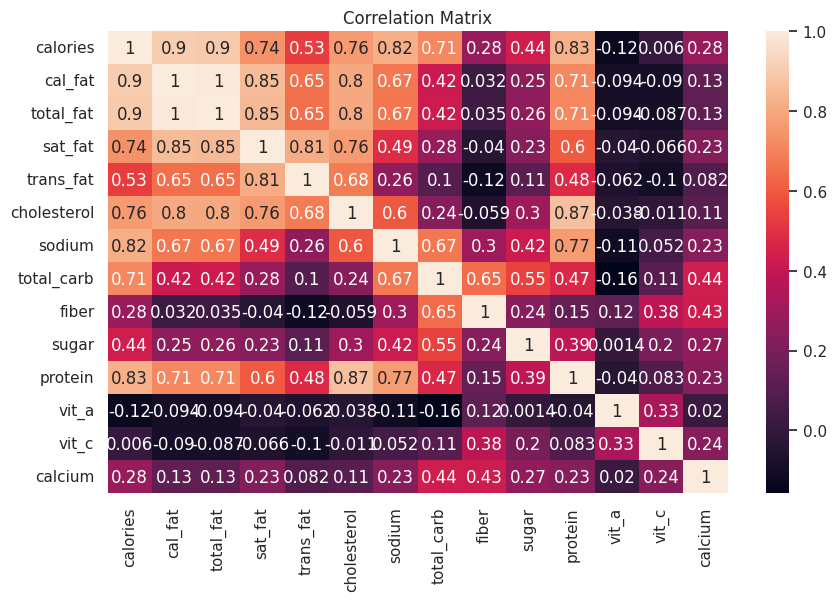

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

✏️ Explanation:
- This heatmap shows the correlation between numeric columns (such as calories, fat, sodium, etc.).
- The values in the cells represent how strongly two variables are related (values close to 1 show a strong relationship, while values close to 0 show a weak relationship).
- Why choose this plot? To see relationships between numeric variables

💡 Insight:
- Calories and fat have a strong positive correlation (as expected, more calories often means more fat).
- There’s also a positive relationship between sodium and calories, which is a red flag for health-conscious consumers.

## 📊 Top Values Analysis

## 8. Top 10 Highest Calorie Items

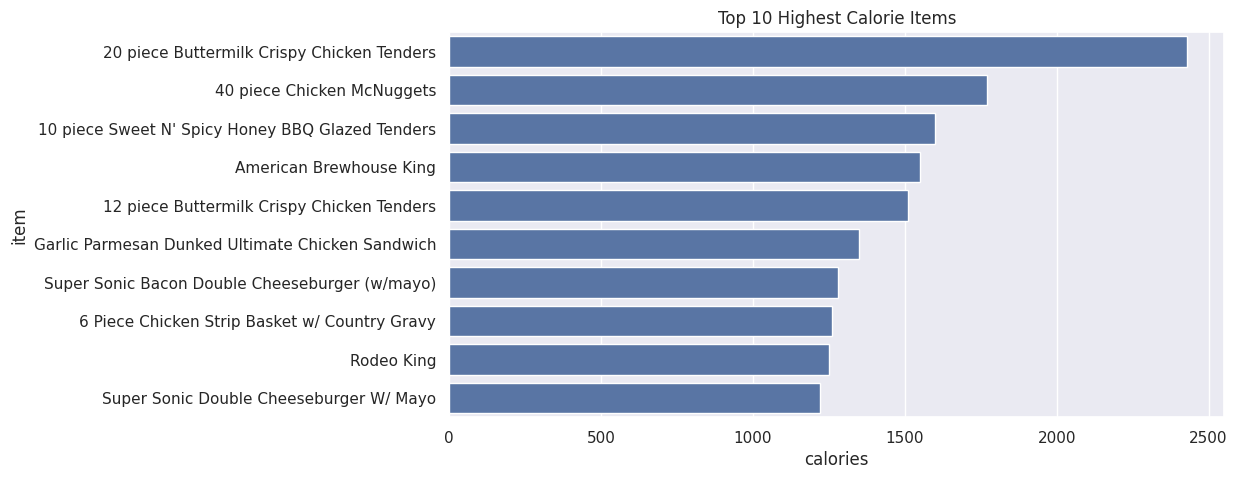

In [21]:
top_calories = df[['item', 'calories']].sort_values(by='calories', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x='calories', y='item', data=top_calories)
plt.title("Top 10 Highest Calorie Items")
plt.show()

✏️ Explanation:
- Displays the top 10 items with the highest calories in the dataset.

💡 Insight:
- The highest calorie items tend to be larger meals.
- If you’re watching your calorie intake, these should probably be avoided or eaten in moderation.


# **Final Insights and Conclusions**

- The dataset shows that most fast food items are high in calories and fat, which may not be healthy if consumed frequently.
- The distribution plots revealed that many items have moderate values, but there are some extreme high-calorie and high-fat items.
- From the restaurant comparison, some restaurants offer higher calorie meals on average, indicating differences in menu healthiness.
- The scatter plot showed a positive relationship between calories and sodium, meaning higher calorie foods tend to have more salt.
- The correlation analysis confirmed strong relationships between calories, fat, and sodium, which are important nutritional factors.
- The top 10 highest calorie items highlight meals that should be consumed carefully or in moderation.

Overall, this analysis helps understand the nutritional patterns of fast food and can help people make healthier food choices.

### **Assignment**

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
3. Jupyter Notebook
